# 02 — Statistical Analysis

**Project:** Gaming Launch Intelligence — Predicting Commercial Success and Optimising Platform & Launch Strategy

**Objective:** Apply formal statistical tests to validate the exploratory findings from Notebook 01 and the SQL analysis, providing quantitative evidence for each business recommendation.

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import shapiro, kruskal, spearmanr, pearsonr, mannwhitneyu
import sklearn
import warnings

# Ensure Plotly charts render as static images on GitHub
pio.renderers.default = 'notebook_connected'
# Suppress interactive HTML diagram widget for scikit-learn estimators
sklearn.set_config(display='text')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

FIGURES_DIR = '../outputs/figures'
SQL_RESULTS_DIR = '../../SQL_Analysis/Result'

In [2]:
# ============================================================
# Outputs directory
# ============================================================

from pathlib import Path

# Project root
PROJECT_ROOT = Path("../..")

# Existing project output directory
OUTPUTS_DIR = PROJECT_ROOT / "Python_Analysis" / "outputs"

# All figures from all notebooks go here
FIGURES_DIR = OUTPUTS_DIR / "figures"

# Create the directories if they don't already exist
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Outputs:", OUTPUTS_DIR.resolve())
print("Figures:", FIGURES_DIR.resolve())

Outputs: C:\Users\USER\Desktop\Resume Projects\Game_Launch_Intelligence\Python_Analysis\outputs
Figures: C:\Users\USER\Desktop\Resume Projects\Game_Launch_Intelligence\Python_Analysis\outputs\figures


In [3]:

# Plotly export helper
# PNG is preferred. If Kaleido is unavailable, save an interactive HTML
# copy instead so notebook execution does not fail.
def save_plotly_figure(fig, filename, scale=2):
    output_path = FIGURES_DIR / filename
    try:
        fig.write_image(output_path, scale=scale)
        print(f"Figure saved: {output_path}")
    except (ValueError, ImportError) as exc:
        html_path = output_path.with_suffix(".html")
        fig.write_html(html_path, include_plotlyjs="cdn")
        print(
            f"Kaleido image export unavailable. "
            f"Saved interactive figure instead: {html_path}"
        )


In [4]:
# Load cleaned dataset from Notebook 01
df = pd.read_csv('../outputs/cleaned_dataset.csv', parse_dates=['release_date', 'last_update'])
df['release_year'] = df['release_date'].dt.year.astype('Int64')

# Analysis window
ANALYSIS_START = 2006
ANALYSIS_END = 2018
df_scoped = df[(df['release_year'] >= ANALYSIS_START) & (df['release_year'] <= ANALYSIS_END)].copy()

print(f'Full dataset: {len(df):,} rows')
print(f'Analysis window ({ANALYSIS_START}-{ANALYSIS_END}): {len(df_scoped):,} rows')

Full dataset: 18,850 rows
Analysis window (2006-2018): 12,713 rows


## 2. Distribution Analysis

### Are game sales normally distributed?

This determines whether we should use parametric (t-test, ANOVA) or non-parametric (Mann-Whitney, Kruskal-Wallis) tests throughout the analysis.

In [5]:
# Shapiro-Wilk test on a random sample (test is limited to n <= 5000)
sample = df_scoped['total_sales'].dropna().sample(n=min(5000, len(df_scoped)), random_state=42)
stat, p_value = shapiro(sample)

print('Shapiro-Wilk Normality Test')
print(f'  Statistic: {stat:.6f}')
print(f'  p-value:   {p_value:.2e}')
print(f'  Result:    {"NOT normally distributed" if p_value < 0.05 else "Normally distributed"} (alpha=0.05)')
print()
print(f'  Skewness:  {df_scoped["total_sales"].skew():.2f}')
print(f'  Kurtosis:  {df_scoped["total_sales"].kurtosis():.2f}')
print()
print('Implication: Non-parametric tests (Kruskal-Wallis, Spearman) are required.')

Shapiro-Wilk Normality Test
  Statistic: 0.342819
  p-value:   3.59e-86
  Result:    NOT normally distributed (alpha=0.05)

  Skewness:  9.11
  Kurtosis:  125.48

Implication: Non-parametric tests (Kruskal-Wallis, Spearman) are required.


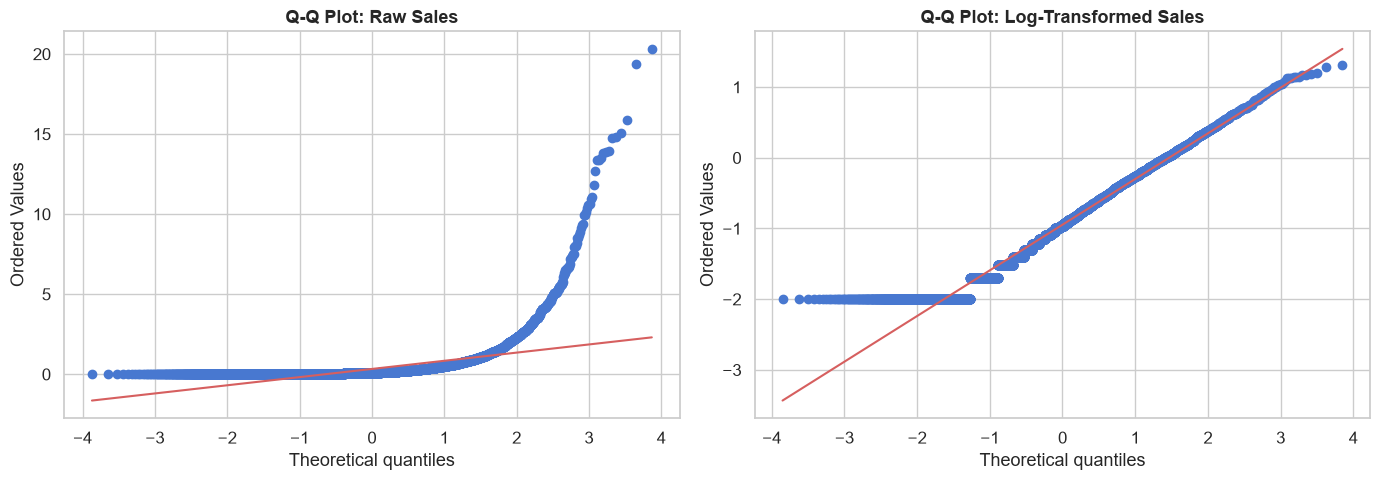

In [6]:
# Q-Q plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw sales
stats.probplot(df_scoped['total_sales'].dropna(), dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: Raw Sales', fontweight='bold')

# Log-transformed sales
log_sales = np.log10(df_scoped['total_sales'][df_scoped['total_sales'] > 0])
stats.probplot(log_sales, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Log-Transformed Sales', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/qq_plots.png', bbox_inches='tight')
plt.show()

## 3. Platform Sales Comparison

### Q1: Are sales differences between platforms statistically significant?

Using Kruskal-Wallis (non-parametric ANOVA) to test whether at least one platform's sales distribution differs significantly from the others, followed by pairwise Mann-Whitney U tests for the top platforms.

In [7]:
# Kruskal-Wallis test across all platforms
platform_groups = [
    group['total_sales'].values
    for _, group in df_scoped.groupby('console')
    if len(group) >= 20
]

h_stat, p_value = kruskal(*platform_groups)
print('Kruskal-Wallis Test: Platform Sales Differences')
print(f'  H-statistic: {h_stat:.2f}')
print(f'  p-value:     {p_value:.2e}')
print(f'  Result:      {"Significant" if p_value < 0.05 else "Not significant"} differences exist between platforms')

Kruskal-Wallis Test: Platform Sales Differences
  H-statistic: 2097.20
  p-value:     0.00e+00
  Result:      Significant differences exist between platforms


In [8]:
# Pairwise Mann-Whitney U tests for the top 8 platforms
from itertools import combinations

top_platforms = df_scoped.groupby('console')['total_sales'].sum().nlargest(8).index.tolist()
pairwise_results = []

for p1, p2 in combinations(top_platforms, 2):
    g1 = df_scoped[df_scoped['console'] == p1]['total_sales']
    g2 = df_scoped[df_scoped['console'] == p2]['total_sales']
    u_stat, p_val = mannwhitneyu(g1, g2, alternative='two-sided')
    pairwise_results.append({
        'Platform A': p1, 'Platform B': p2,
        'U-stat': round(u_stat, 0),
        'p-value': p_val,
        'Significant': 'Yes' if p_val < 0.05 else 'No',
        'Median A': round(g1.median(), 4),
        'Median B': round(g2.median(), 4)
    })

pairwise_df = pd.DataFrame(pairwise_results).sort_values('p-value')
print('Pairwise Mann-Whitney U Tests (Top 8 Platforms)')
print(f'Significant pairs: {pairwise_df["Significant"].value_counts().get("Yes", 0)} / {len(pairwise_df)}')
pairwise_df.head(15)

Pairwise Mann-Whitney U Tests (Top 8 Platforms)
Significant pairs: 25 / 28


,Platform A,Platform B,U-stat,p-value,Significant,Median A,Median B
6,X360,PSP,1173184.0,2.115635e-97,Yes,0.25,0.05
3,X360,DS,2042528.0,2.613622e-95,Yes,0.25,0.08
12,PS3,PSP,1217824.0,6.626402e-95,Yes,0.24,0.05
9,PS3,DS,2115722.0,1.131427e-91,Yes,0.24,0.08
21,WII,PSP,1118170.0,2.749274e-52,Yes,0.16,0.05
18,WII,DS,1916650.0,1.637697e-41,Yes,0.16,0.08
5,X360,PS2,740248.0,3.805994e-36,Yes,0.25,0.09
11,PS3,PS2,769148.0,8.148542e-35,Yes,0.24,0.09
17,PS4,PSP,693780.0,3.605626e-26,Yes,0.11,0.05
26,XONE,PSP,425868.0,4.186688e-25,Yes,0.12,0.05


In [9]:
# Effect size: median sales per platform with confidence intervals (bootstrap)
platform_medians = (
    df_scoped[df_scoped['console'].isin(top_platforms)]
    .groupby('console')['total_sales']
    .agg(['median', 'mean', 'count', 'std'])
    .sort_values('median', ascending=False)
    .reset_index()
)

fig = px.bar(
    platform_medians, x='median', y='console', orientation='h',
    color='median', color_continuous_scale='Viridis',
    error_x='std',
    labels={'median': 'Median Sales (M$)', 'console': ''},
    title='Median Sales per Release by Platform (with Std Dev)'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=400, showlegend=False)
save_plotly_figure(fig, 'platform_median_sales.png', scale=2)
# Figure is saved to FIGURES_DIR; display is optional.

Figure saved: ..\..\Python_Analysis\outputs\figures\platform_median_sales.png


## 4. Genre Sales Comparison

### Q2: Which genres significantly outperform others?

In [10]:
# Kruskal-Wallis test across genres
genre_groups = [
    group['total_sales'].values
    for _, group in df_scoped[df_scoped['genre'].notna()].groupby('genre')
    if len(group) >= 20
]

h_stat, p_value = kruskal(*genre_groups)
print('Kruskal-Wallis Test: Genre Sales Differences')
print(f'  H-statistic: {h_stat:.2f}')
print(f'  p-value:     {p_value:.2e}')
print(f'  Result:      {"Significant" if p_value < 0.05 else "Not significant"} differences exist between genres')

Kruskal-Wallis Test: Genre Sales Differences
  H-statistic: 1264.30
  p-value:     2.33e-259
  Result:      Significant differences exist between genres


In [11]:
# Genre summary statistics
genre_summary = (
    df_scoped[df_scoped['genre'].notna()]
    .groupby('genre')['total_sales']
    .agg(['count', 'mean', 'median', 'std', 'sum'])
    .sort_values('median', ascending=False)
    .round(4)
    .reset_index()
)
genre_summary.columns = ['Genre', 'Count', 'Mean', 'Median', 'Std', 'Total']
genre_summary

,Genre,Count,Mean,Median,Std,Total
0,Sandbox,1,1.8900,1.89,NaN,1.89
1,Education,2,0.3800,0.38,0.1980,0.76
2,Action-Adventure,259,0.5695,0.22,1.2183,147.50
3,Shooter,866,0.8635,0.21,1.9510,747.79
4,Sports,1515,0.4690,0.17,0.9138,710.53
5,Music,145,0.3569,0.16,0.7155,51.75
6,Platform,459,0.3175,0.14,0.4894,145.75
7,Party,27,0.2237,0.14,0.2275,6.04
8,Action,1969,0.3791,0.13,1.0534,746.38
9,Fighting,465,0.3372,0.12,0.5159,156.78


## 5. Regional Sales Correlation

### Q3: How correlated are sales across regions?

Understanding regional independence determines whether success in one region predicts success in others, and guides marketing diversification strategy.

In [12]:
# Spearman rank correlation matrix (robust to non-normality)
region_cols = ['na_sales', 'jp_sales', 'pal_sales', 'other_sales']
region_labels = ['North America', 'Japan', 'Europe (PAL)', 'Other']

region_data = df_scoped[region_cols].dropna()
corr_matrix = region_data.corr(method='spearman')
corr_matrix.index = region_labels
corr_matrix.columns = region_labels

# Significance testing
print('Spearman Correlation Matrix with p-values:')
print('=' * 60)
for i, r1 in enumerate(region_cols):
    for j, r2 in enumerate(region_cols):
        if i < j:
            rho, p = spearmanr(region_data[r1], region_data[r2])
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            print(f'  {region_labels[i]:20s} vs {region_labels[j]:20s}: rho={rho:.4f}, p={p:.2e} {sig}')

Spearman Correlation Matrix with p-values:
  North America        vs Japan               : rho=-0.0226, p=3.52e-01 ns
  North America        vs Europe (PAL)        : rho=0.7053, p=2.81e-256 ***
  North America        vs Other               : rho=0.8184, p=0.00e+00 ***
  Japan                vs Europe (PAL)        : rho=0.0372, p=1.25e-01 ns
  Japan                vs Other               : rho=0.0466, p=5.46e-02 ns
  Europe (PAL)         vs Other               : rho=0.8887, p=0.00e+00 ***


In [13]:
# Correlation heatmap
fig = px.imshow(
    corr_matrix, color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1, text_auto='.3f',
    labels=dict(color='Spearman rho'),
    title='Regional Sales Correlation Matrix (Spearman)',
    aspect='auto'
)
fig.update_layout(height=500, width=600)
save_plotly_figure(fig, 'regional_correlation_heatmap.png', scale=2)
# Figure is saved to FIGURES_DIR; display is optional.

Figure saved: ..\..\Python_Analysis\outputs\figures\regional_correlation_heatmap.png


## 6. Critic Score Impact on Sales

### Q4: Does critical acclaim significantly predict commercial success?

In [14]:
scored = df_scoped[df_scoped['critic_score'].notna()].copy()

# Spearman correlation
rho, p_value = spearmanr(scored['critic_score'], scored['total_sales'])
print('Spearman Correlation: Critic Score vs Total Sales')
print(f'  rho:     {rho:.4f}')
print(f'  p-value: {p_value:.2e}')
print(f'  Result:  {"Significant" if p_value < 0.05 else "Not significant"} positive correlation')
print()

# Compare top-quartile vs bottom-quartile critic scores
q1 = scored['critic_score'].quantile(0.25)
q3 = scored['critic_score'].quantile(0.75)
low_scored = scored[scored['critic_score'] <= q1]['total_sales']
high_scored = scored[scored['critic_score'] >= q3]['total_sales']

u_stat, p_val = mannwhitneyu(high_scored, low_scored, alternative='greater')
print(f'Mann-Whitney U: High-rated (>={q3}) vs Low-rated (<={q1})')
print(f'  U-stat:  {u_stat:.0f}')
print(f'  p-value: {p_val:.2e}')
print(f'  Median sales (high): {high_scored.median():.4f}M')
print(f'  Median sales (low):  {low_scored.median():.4f}M')
print(f'  Ratio:   {high_scored.median() / low_scored.median():.2f}x')

Spearman Correlation: Critic Score vs Total Sales
  rho:     0.3723
  p-value: 3.99e-91
  Result:  Significant positive correlation

Mann-Whitney U: High-rated (>=8.1) vs Low-rated (<=6.3)
  U-stat:  390935
  p-value: 3.51e-64
  Median sales (high): 0.7600M
  Median sales (low):  0.2000M
  Ratio:   3.80x


## 7. Market Share Trend Testing

### Q2: Which genres are statistically growing or declining?

Using the Mann-Kendall trend test — a non-parametric test for monotonic trend in time series data.

In [15]:
def mann_kendall_test(data):
    """Manual Mann-Kendall trend test implementation."""
    n = len(data)
    s = 0
    for k in range(n - 1):
        for j in range(k + 1, n):
            diff = data[j] - data[k]
            if diff > 0:
                s += 1
            elif diff < 0:
                s -= 1

    # Variance of S
    var_s = n * (n - 1) * (2 * n + 5) / 18

    # Z-statistic
    if s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0

    p_value = 2 * (1 - stats.norm.cdf(abs(z)))
    trend = 'increasing' if z > 0 and p_value < 0.05 else 'decreasing' if z < 0 and p_value < 0.05 else 'no trend'

    return {'S': s, 'Z': round(z, 4), 'p_value': round(p_value, 6), 'trend': trend}


# Calculate annual market share per genre
yearly_genre = (
    df_scoped[df_scoped['genre'].notna()]
    .groupby(['release_year', 'genre'])['total_sales']
    .sum()
    .reset_index()
)
yearly_total = df_scoped.groupby('release_year')['total_sales'].sum().reset_index()
yearly_total.columns = ['release_year', 'market_total']
yearly_genre = yearly_genre.merge(yearly_total, on='release_year')
yearly_genre['market_share_pct'] = yearly_genre['total_sales'] / yearly_genre['market_total'] * 100

# Run Mann-Kendall on each genre
trend_results = []
for genre, gdata in yearly_genre.groupby('genre'):
    gdata = gdata.sort_values('release_year')
    if len(gdata) >= 5:
        result = mann_kendall_test(gdata['market_share_pct'].values)
        result['genre'] = genre
        result['avg_share'] = round(gdata['market_share_pct'].mean(), 2)
        trend_results.append(result)

trend_df = pd.DataFrame(trend_results).sort_values('Z', ascending=False)
trend_df = trend_df[['genre', 'avg_share', 'S', 'Z', 'p_value', 'trend']]
print('Mann-Kendall Trend Test Results by Genre')
print('=' * 70)
trend_df

Mann-Kendall Trend Test Results by Genre


,genre,avg_share,S,Z,p_value,trend
12,Shooter,19.09,48,2.8674,0.004138,increasing
1,Action-Adventure,6.61,19,1.6100,0.107405,no trend
7,Party,0.34,14,1.6083,0.107762,no trend
16,Visual Novel,0.23,17,1.4311,0.152406,no trend
11,Role-Playing,7.49,24,1.4032,0.160556,no trend
14,Sports,17.24,18,1.0372,0.299665,no trend
6,Music,1.86,11,0.7785,0.436275,no trend
5,Mmo,0.60,1,0.0000,1.000000,no trend
8,Platform,3.49,-6,-0.3050,0.760332,no trend
0,Action,17.28,-8,-0.4271,0.669334,no trend


## 8. Publisher Concentration (Gini Coefficients)

The Gini coefficient measures inequality in publisher sales within each genre. A Gini near 0 means sales are spread equally; near 1 means one publisher dominates.

In [16]:
def gini_coefficient(values):
    """Calculate Gini coefficient for a list of values."""
    values = np.sort(np.array(values, dtype=float))
    n = len(values)
    if n == 0 or values.sum() == 0:
        return 0
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * values) - (n + 1) * np.sum(values)) / (n * np.sum(values))


# Gini by genre
pub_sales = (
    df_scoped[df_scoped['genre'].notna()]
    .groupby(['genre', 'publisher'])['total_sales']
    .sum()
    .reset_index()
)

gini_results = []
for genre, gdata in pub_sales.groupby('genre'):
    g = gini_coefficient(gdata['total_sales'].values)
    gini_results.append({
        'genre': genre,
        'gini': round(g, 4),
        'publishers': len(gdata),
        'top_publisher': gdata.nlargest(1, 'total_sales')['publisher'].iloc[0],
        'top_publisher_share': round(gdata.nlargest(1, 'total_sales')['total_sales'].iloc[0] / gdata['total_sales'].sum() * 100, 2)
    })

gini_df = pd.DataFrame(gini_results).sort_values('gini', ascending=False)
gini_df

,genre,gini,publishers,top_publisher,top_publisher_share
15,Shooter,0.9309,123,Activision,44.13
17,Sports,0.9209,125,Ea Sports,40.84
16,Simulation,0.9038,167,Electronic Arts,27.58
0,Action,0.8935,196,Rockstar Games,15.43
6,Misc,0.8847,222,Activision,15.05
13,Role-Playing,0.8819,148,Bethesda Softworks,21.18
12,Racing,0.8728,109,Electronic Arts,27.10
2,Adventure,0.8657,236,Warner Bros. Interactive,11.50
10,Platform,0.8633,87,Activision,26.03
8,Music,0.8456,30,Ubisoft,66.63


In [17]:
# Lorenz curves for top 6 genres by sales
top_genres = df_scoped[df_scoped['genre'].notna()].groupby('genre')['total_sales'].sum().nlargest(6).index

fig = go.Figure()
for genre in top_genres:
    genre_pubs = pub_sales[pub_sales['genre'] == genre]['total_sales'].sort_values().values
    cum_share = np.cumsum(genre_pubs) / genre_pubs.sum()
    cum_pop = np.arange(1, len(genre_pubs) + 1) / len(genre_pubs)
    fig.add_trace(go.Scatter(x=cum_pop, y=cum_share, mode='lines', name=genre, line=dict(width=2)))

# Line of equality
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Perfect Equality',
                          line=dict(dash='dash', color='gray', width=1)))

fig.update_layout(
    title='Lorenz Curves: Publisher Sales Concentration by Genre',
    xaxis_title='Cumulative Share of Publishers',
    yaxis_title='Cumulative Share of Sales',
    height=500, width=600
)
save_plotly_figure(fig, 'lorenz_curves.png', scale=2)
# Figure is saved to FIGURES_DIR; display is optional.

Figure saved: ..\..\Python_Analysis\outputs\figures\lorenz_curves.png



## 9. Pre-Launch Commercial Success Modelling

### Business question

> Before launch, how much can historical information tell us about the probability that a game will become a commercially strong title?

This section is deliberately different from the earlier descriptive analysis.

The model is a **pre-launch decision-support model**. It must not use information that would only become available after launch, such as the game's own critic score or its own sales.

### Success definition

A game is labelled successful when its final sales are in the top quartile of games within its **genre and three-year release cohort**.

This creates a relative commercial-success benchmark rather than applying one fixed sales threshold to every era and genre.


In [18]:

# ============================================================
# 9.1 Predictive modelling imports and output paths
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss,
    confusion_matrix,
    classification_report
)
from sklearn.inspection import permutation_importance

# Use the single project output directory already defined above.
# No additional output subfolders are created.
MODEL_OUTPUT_DIR = OUTPUTS_DIR



### 9.2 Build the commercial-success target

The cohort is defined by genre and three-year release period.

Very small cohorts are excluded from model training because a percentile threshold from a tiny group is unstable.


In [19]:

# ============================================================
# 9.2 Success target
# ============================================================

model_df = df_scoped[
    df_scoped["genre"].notna()
    & df_scoped["total_sales"].notna()
    & df_scoped["release_date"].notna()
].copy()

model_df["release_year"] = (
    model_df["release_date"].dt.year.astype(int)
)

model_df["cohort_start"] = (
    (model_df["release_year"] // 3) * 3
)

cohort_cols = ["genre", "cohort_start"]

model_df["cohort_size"] = (
    model_df.groupby(cohort_cols)["total_sales"]
    .transform("size")
)

MIN_COHORT_SIZE = 20

model_df["success_threshold"] = np.nan

eligible = model_df["cohort_size"] >= MIN_COHORT_SIZE

model_df.loc[eligible, "success_threshold"] = (
    model_df.loc[eligible]
    .groupby(cohort_cols)["total_sales"]
    .transform(lambda s: s.quantile(0.75))
)

model_df["is_success"] = np.where(
    model_df["success_threshold"].notna(),
    (model_df["total_sales"] >= model_df["success_threshold"]).astype(int),
    np.nan
)

model_df = model_df[
    model_df["is_success"].notna()
].copy()

model_df["is_success"] = model_df["is_success"].astype(int)

print(f"Eligible modelling rows: {len(model_df):,}")
print(f"Success rate: {model_df['is_success'].mean():.1%}")
print(
    f"Success threshold cohorts: "
    f"{model_df.groupby(cohort_cols).ngroups:,}"
)


Eligible modelling rows: 12,645
Success rate: 25.7%
Success threshold cohorts: 69



### 9.3 Platform family

The original platform field is retained, while a broader family is created for the strategic decision layer.


In [20]:

def map_platform_family(platform):
    p = str(platform).upper().strip()

    if p == "PC":
        return "PC"

    if p.startswith("PS"):
        return "PlayStation"

    if p.startswith("XBOX") or p in {"XB", "X360", "XONE", "XS", "XBS"}:
        return "Xbox"

    if p.startswith(("WII", "DS", "3DS")) or p in {
        "GC", "GBA", "N64", "NES", "SNES", "NS", "WIIU"
    }:
        return "Nintendo"

    return "Other"


model_df["platform_family"] = (
    model_df["console"].apply(map_platform_family)
)

model_df["release_month"] = (
    model_df["release_date"].dt.month
)

model_df["is_holiday_window"] = (
    model_df["release_month"].isin([9, 10, 11, 12]).astype(int)
)



### 9.4 Leakage-controlled historical features

For every game, historical publisher, developer, genre and platform metrics are calculated from **earlier releases only**.

The current game is never included in its own historical track record.

These features represent information that could plausibly be available when a launch decision is being made.


In [21]:

# ============================================================
# 9.4 Historical track-record features
# ============================================================

feature_df = model_df.sort_values(
    ["release_date", "title", "console"]
).copy()

def add_prior_features(data, group_col):
    result = data.copy()

    # Prior release count
    result[f"{group_col}_prior_count"] = (
        result.groupby(group_col).cumcount()
    )

    # Prior cumulative sales
    cumulative_sales = (
        result.groupby(group_col)["total_sales"]
        .cumsum()
    )

    result[f"{group_col}_prior_sales"] = (
        cumulative_sales - result["total_sales"]
    )

    result[f"{group_col}_prior_avg_sales"] = (
        result[f"{group_col}_prior_sales"]
        / result[f"{group_col}_prior_count"].replace(0, np.nan)
    )

    # Prior median sales. We use expanding median and shift it so
    # the current game's sales are never included.
    result[f"{group_col}_prior_median_sales"] = (
        result.groupby(group_col)["total_sales"]
        .transform(
            lambda s: s.shift(1).expanding().median()
        )
    )

    return result


for group_col in ["publisher", "developer", "genre", "console"]:
    feature_df = add_prior_features(
        feature_df,
        group_col
    )


# Historical success rate
def add_prior_success_rate(data, group_col):
    result = data.copy()

    prior_successes = (
        result.groupby(group_col)["is_success"]
        .cumsum()
        - result["is_success"]
    )

    prior_count = (
        result.groupby(group_col).cumcount()
    )

    result[f"{group_col}_prior_hit_rate"] = (
        prior_successes
        / prior_count.replace(0, np.nan)
    )

    return result


for group_col in ["publisher", "developer", "genre", "console"]:
    feature_df = add_prior_success_rate(
        feature_df,
        group_col
    )

print("Historical features created.")


Historical features created.



### 9.5 Temporal evaluation design

We simulate the information available at different points in time.

- **Training:** 2006–2015
- **Validation:** 2016–2017
- **Final holdout:** 2018

The 2018 holdout is not used to select the model or probability threshold.


In [22]:

# ============================================================
# 9.5 Temporal train / validation / test split
# ============================================================

train_df = feature_df[
    feature_df["release_year"] <= 2015
].copy()

validation_df = feature_df[
    feature_df["release_year"].between(2016, 2017)
].copy()

test_df = feature_df[
    feature_df["release_year"] == 2018
].copy()

print("Training:", f"{len(train_df):,}")
print("Validation:", f"{len(validation_df):,}")
print("2018 Holdout:", f"{len(test_df):,}")

for name, part in [
    ("Training", train_df),
    ("Validation", validation_df),
    ("Test", test_df)
]:
    print(
        f"{name} success rate: "
        f"{part['is_success'].mean():.1%}"
    )


Training: 10,716
Validation: 1,283
2018 Holdout: 646
Training success rate: 25.4%
Validation success rate: 29.3%
Test success rate: 22.0%



### 9.6 Model features

Only launch-time information and historical track records are used.

**Excluded deliberately:**
- the current game's critic score
- the current game's user score
- current-game sales
- current/future publisher sales
- current/future platform popularity
- any post-launch review information


In [23]:

numeric_features = [
    "publisher_prior_count",
    "publisher_prior_avg_sales",
    "publisher_prior_median_sales",
    "publisher_prior_hit_rate",

    "developer_prior_count",
    "developer_prior_avg_sales",
    "developer_prior_median_sales",
    "developer_prior_hit_rate",

    "genre_prior_count",
    "genre_prior_avg_sales",
    "genre_prior_median_sales",
    "genre_prior_hit_rate",

    "console_prior_count",
    "console_prior_avg_sales",
    "console_prior_median_sales",
    "console_prior_hit_rate",

    "release_month",
    "is_holiday_window"
]

categorical_features = [
    "genre",
    "platform_family"
]

model_features = numeric_features + categorical_features

X_train = train_df[model_features]
y_train = train_df["is_success"]

X_val = validation_df[model_features]
y_val = validation_df["is_success"]

X_test = test_df[model_features]
y_test = test_df["is_success"]



### 9.7 Train candidate models

Two models are compared:

1. **Logistic Regression** for interpretability.
2. **Random Forest** for nonlinear relationships.

The validation period determines which model is selected.


In [24]:

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        C=0.5,
        random_state=42
    ))
])

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

logistic_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

def evaluate_probabilities(model, X, y, threshold=0.50):
    probability = model.predict_proba(X)[:, 1]
    prediction = (probability >= threshold).astype(int)

    return {
        "ROC_AUC": roc_auc_score(y, probability),
        "PR_AUC": average_precision_score(y, probability),
        "Precision": precision_score(y, prediction, zero_division=0),
        "Recall": recall_score(y, prediction, zero_division=0),
        "F1": f1_score(y, prediction, zero_division=0),
        "Brier": brier_score_loss(y, probability)
    }

validation_comparison = pd.DataFrame({
    "Logistic Regression": evaluate_probabilities(
        logistic_model, X_val, y_val
    ),
    "Random Forest": evaluate_probabilities(
        random_forest_model, X_val, y_val
    )
}).T.sort_values("ROC_AUC", ascending=False)

validation_comparison


,ROC_AUC,PR_AUC,Precision,Recall,F1,Brier
Random Forest,0.840537,0.681805,0.611628,0.699468,0.652605,0.155492
Logistic Regression,0.840349,0.658985,0.568826,0.747340,0.645977,0.164385



### 9.8 Select the model

Model selection is based only on validation ROC-AUC.

The final 2018 holdout remains untouched.


In [25]:

best_model_name = validation_comparison["ROC_AUC"].idxmax()

best_model = (
    logistic_model
    if best_model_name == "Logistic Regression"
    else random_forest_model
)

print("Selected model:", best_model_name)


Selected model: Random Forest



### 9.9 Select the decision threshold

A 0.50 probability threshold is not automatically the best business threshold.

We select the threshold that maximises validation F1 and freeze it before the 2018 holdout evaluation.


In [26]:

val_prob = best_model.predict_proba(X_val)[:, 1]

threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.01):
    val_pred = (val_prob >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(
            y_val, val_pred, zero_division=0
        ),
        "recall": recall_score(
            y_val, val_pred, zero_division=0
        ),
        "f1": f1_score(
            y_val, val_pred, zero_division=0
        )
    })

threshold_df = pd.DataFrame(threshold_rows)

best_threshold = float(
    threshold_df.loc[
        threshold_df["f1"].idxmax(),
        "threshold"
    ]
)

print(
    f"Validation-selected threshold: "
    f"{best_threshold:.2f}"
)


Validation-selected threshold: 0.44



### 9.10 Final 2018 holdout evaluation

The model and threshold are now frozen.

No tuning is performed using the 2018 results.


In [27]:

test_prob = best_model.predict_proba(X_test)[:, 1]

test_pred = (
    test_prob >= best_threshold
).astype(int)

final_metrics = pd.DataFrame([{
    "model": best_model_name,
    "test_period": 2018,
    "threshold": best_threshold,
    "ROC_AUC": roc_auc_score(y_test, test_prob),
    "PR_AUC": average_precision_score(y_test, test_prob),
    "Precision": precision_score(
        y_test, test_pred, zero_division=0
    ),
    "Recall": recall_score(
        y_test, test_pred, zero_division=0
    ),
    "F1": f1_score(
        y_test, test_pred, zero_division=0
    ),
    "Brier": brier_score_loss(
        y_test, test_prob
    )
}])

final_metrics


,model,test_period,threshold,ROC_AUC,PR_AUC,Precision,Recall,F1,Brier
0,Random Forest,2018,0.44,0.85038,0.619044,0.506912,0.774648,0.612813,0.142048


In [28]:

print("2018 holdout classification report")
print(
    classification_report(
        y_test,
        test_pred,
        zero_division=0
    )
)

print("2018 confusion matrix")
print(
    confusion_matrix(
        y_test,
        test_pred
    )
)


2018 holdout classification report
              precision    recall  f1-score   support

           0       0.93      0.79      0.85       504
           1       0.51      0.77      0.61       142

    accuracy                           0.78       646
   macro avg       0.72      0.78      0.73       646
weighted avg       0.83      0.78      0.80       646

2018 confusion matrix
[[397 107]
 [ 32 110]]



### 9.11 Probability calibration

The model is used downstream as a probability signal, so probability quality matters.

We compare predicted probability bands with the observed success rate in the 2018 holdout.


In [29]:

calibration_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted_probability": test_prob
})

calibration_df["probability_bin"] = pd.cut(
    calibration_df["predicted_probability"],
    bins=np.arange(0, 1.01, 0.10),
    include_lowest=True
)

calibration_summary = (
    calibration_df
    .groupby("probability_bin", observed=True)
    .agg(
        observations=("actual", "size"),
        mean_predicted_probability=(
            "predicted_probability",
            "mean"
        ),
        observed_success_rate=("actual", "mean")
    )
    .reset_index()
)

calibration_summary


,probability_bin,observations,mean_predicted_probability,observed_success_rate
0,"(-0.001, 0.1]",31,0.077032,0.000000
1,"(0.1, 0.2]",160,0.149157,0.031250
2,"(0.2, 0.3]",133,0.247521,0.090226
3,"(0.3, 0.4]",78,0.349449,0.089744
4,"(0.4, 0.5]",61,0.447608,0.278689
5,"(0.5, 0.6]",55,0.539590,0.381818
6,"(0.6, 0.7]",58,0.649466,0.586207
7,"(0.7, 0.8]",54,0.754025,0.592593
8,"(0.8, 0.9]",16,0.838005,0.875000



### 9.12 Feature importance

Permutation importance is evaluated on the validation set.

This answers which variables the model relies on most for discrimination. It is not a causal-effect estimate.


In [30]:

permutation = permutation_importance(
    best_model,
    X_val,
    y_val,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_mean": permutation.importances_mean,
    "importance_std": permutation.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

importance_df.head(20)


,feature,importance_mean,importance_std
9,genre_prior_avg_sales,0.023256,0.002473
3,publisher_prior_hit_rate,0.018715,0.004810
10,genre_prior_median_sales,0.014009,0.001847
7,developer_prior_hit_rate,0.013970,0.003301
1,publisher_prior_avg_sales,0.011366,0.004307
5,developer_prior_avg_sales,0.006049,0.002566
15,console_prior_hit_rate,0.005490,0.001655
19,platform_family,0.003896,0.000984
12,console_prior_count,0.003066,0.000508
13,console_prior_avg_sales,0.002311,0.001672



### 9.13 Robustness by platform and genre

Overall model performance can hide weak segments.

We therefore calculate holdout ROC-AUC for sufficiently large platform and genre groups.


In [31]:

def segment_auc(data, probabilities, segment_col, min_n=30):
    temp = data[[segment_col, "is_success"]].copy()
    temp["probability"] = probabilities

    rows = []

    for segment, group in temp.groupby(segment_col):
        if len(group) < min_n:
            continue

        if group["is_success"].nunique() < 2:
            continue

        rows.append({
            segment_col: segment,
            "n": len(group),
            "success_rate": group["is_success"].mean(),
            "ROC_AUC": roc_auc_score(
                group["is_success"],
                group["probability"]
            )
        })

    if not rows:
        return pd.DataFrame(
            columns=[
                segment_col,
                "n",
                "success_rate",
                "ROC_AUC"
            ]
        )

    return pd.DataFrame(rows).sort_values(
        "ROC_AUC",
        ascending=False
    )

platform_robustness = segment_auc(
    test_df,
    test_prob,
    "platform_family"
)

genre_robustness = segment_auc(
    test_df,
    test_prob,
    "genre"
)

print("Platform robustness")
display(platform_robustness)

print("Genre robustness")
display(genre_robustness.head(20))


Platform robustness


,platform_family,n,success_rate,ROC_AUC
2,Xbox,132,0.242424,0.893125
0,Nintendo,188,0.212766,0.855574
1,PlayStation,306,0.218954,0.847749


Genre robustness


,genre,n,success_rate,ROC_AUC
6,Shooter,30,0.133333,0.971154
1,Action-Adventure,53,0.245283,0.915385
2,Adventure,47,0.361702,0.892157
8,Sports,49,0.183673,0.891667
0,Action,85,0.294118,0.891333
5,Role-Playing,86,0.197674,0.882353
4,Racing,49,0.163265,0.881098
3,Platform,43,0.162791,0.857143
7,Simulation,53,0.207547,0.761905
9,Visual Novel,48,0.104167,0.734884



## 10. Platform Lifecycle Analysis

### Q1: Which platforms are ascending vs. declining?

Tracking each platform's share of annual releases over time provides a descriptive view of platform lifecycle.


In [32]:

# ============================================================
# 10.1 Platform release share over time
# ============================================================

platform_year = (
    df_scoped.groupby(["release_year", "console"])
    .size()
    .reset_index(name="releases")
)

yearly_releases = (
    df_scoped.groupby("release_year")
    .size()
    .reset_index(name="total_releases")
)

platform_year = platform_year.merge(
    yearly_releases,
    on="release_year"
)

platform_year["release_share_pct"] = (
    platform_year["releases"]
    / platform_year["total_releases"]
    * 100
)

top10 = (
    df_scoped["console"]
    .value_counts()
    .nlargest(10)
    .index
)

fig = px.line(
    platform_year[
        platform_year["console"].isin(top10)
    ],
    x="release_year",
    y="release_share_pct",
    color="console",
    markers=True,
    labels={
        "release_year": "Year",
        "release_share_pct": "Release Share (%)",
        "console": "Platform"
    },
    title="Platform Lifecycle: Release Share Over Time"
)

fig.update_layout(height=500)

save_plotly_figure(fig, "platform_lifecycle.png", scale=2)

# Figure is saved to FIGURES_DIR; display is optional.


Figure saved: ..\..\Python_Analysis\outputs\figures\platform_lifecycle.png



## 11. Statistical and Modelling Summary

The notebook now separates **descriptive statistical evidence** from the **pre-launch predictive model**.

The earlier sections test relationships in the historical data. The model section then asks whether launch-time information and historical track records can support a forward-looking commercial-success decision.

### Model governance

- No current-game critic score is used by the predictive model.
- No current-game sales are used as a feature.
- Historical aggregates exclude the current game.
- Model selection uses a validation period.
- The final 2018 period is an untouched holdout.
- Model probability is treated as decision support, not causal proof.

The results below should be interpreted after a clean end-to-end execution.



## 12. Export Phase 1 outputs

All outputs are written directly to:

`Python_Analysis/outputs/`

The **only subfolder** used by this notebook is:

`Python_Analysis/outputs/figures/`

No `results/`, `results/model/`, or `outputs/model/` folder is created.


In [33]:

# ============================================================
# Final Phase 1 CSV exports
# ============================================================

# Game-level predictions
predictions = test_df[
    [
        "title",
        "genre",
        "console",
        "platform_family",
        "release_date",
        "release_year",
        "total_sales",
        "is_success"
    ]
].copy()

predictions["success_probability"] = test_prob
predictions["predicted_success"] = test_pred
predictions["decision_threshold"] = best_threshold

predictions.to_csv(
    OUTPUTS_DIR / "model_success_predictions.csv",
    index=False
)

# Model evaluation
final_metrics.to_csv(
    OUTPUTS_DIR / "model_evaluation.csv",
    index=False
)

# Feature importance
importance_df.to_csv(
    OUTPUTS_DIR / "feature_importance.csv",
    index=False
)

# Threshold analysis
threshold_df.to_csv(
    OUTPUTS_DIR / "threshold_analysis.csv",
    index=False
)

# Calibration
calibration_summary.to_csv(
    OUTPUTS_DIR / "calibration_summary.csv",
    index=False
)

# Robustness diagnostics
platform_robustness.to_csv(
    OUTPUTS_DIR / "platform_robustness.csv",
    index=False
)

genre_robustness.to_csv(
    OUTPUTS_DIR / "genre_robustness.csv",
    index=False
)

print("Phase 1 outputs saved to:")
print(OUTPUTS_DIR.resolve())
print()
print("CSV files created:")

for file in sorted(OUTPUTS_DIR.glob("*.csv")):
    print(" -", file.name)


Phase 1 outputs saved to:
C:\Users\USER\Desktop\Resume Projects\Game_Launch_Intelligence\Python_Analysis\outputs

CSV files created:
 - calibration_summary.csv
 - cleaned_dataset.csv
 - feature_importance.csv
 - genre_robustness.csv
 - model_evaluation.csv
 - model_success_predictions.csv
 - platform_robustness.csv
 - threshold_analysis.csv



## Final output contract

After a successful run, the project should contain:

```text
Python_Analysis/
└── outputs/
    ├── figures/
    │   └── all notebook figures
    ├── model_success_predictions.csv
    ├── model_evaluation.csv
    ├── feature_importance.csv
    ├── threshold_analysis.csv
    ├── calibration_summary.csv
    ├── platform_robustness.csv
    └── genre_robustness.csv
```

The file used by the downstream SQL decision engine is:

`model_success_predictions.csv`
